# If running this notebook on google colab, **change runtime type** and choose T4 gpu.
If running on mac with M chips, you will need to change the device to 'mpu'

In [6]:
import copy
import torch
import sklearn
import numpy as np
import pandas as pd
from torch import nn
from tqdm.notebook import tqdm
import torch.nn.functional as F
import matplotlib.pyplot as plt
# Test whether the notebook is running on google colab or not, and set the data path accordingly
import os
if os.getenv("COLAB_RELEASE_TAG") is None:
    DATA_IN_PATH = '../data'
else:
    DATA_IN_PATH = 'https://raw.githubusercontent.com/rguilcas/BCCR-ML-course/refs/heads/main/lecture_exercises/data'

# Choose seeds for reproducibility
torch.manual_seed(0)
np.random.seed(0)
# Choose GPU device
device = 'cuda' if torch.cuda.is_available() else 'mps' if torch.backends.mps.is_available() else 'cpu'
print(f'Using device: {device}')

Using device: mps


# STEP 1 PREPROCESSING DATA
The first step of the machine learning pipeline is to load the data from a file. Here, our data is stored in the `dataset_energy.csv`. We use the `pandas` library to load the data.

Our dataset contains hourly values from 2020 to 2025.
Once the data is loaded, we need to turn the datasets into an ML friendly array. To do this, we choose the variables necessary for the analysis and then we transform them into numpy arrays.

In [12]:
# Load data
df = pd.read_csv(f'{DATA_IN_PATH}/dataset_energy.csv', index_col=0)
# Choose predictors and prediction variables
X = df[['Pr','Tmin','v_mean','v_max']].values # X is the array containing the data we use to predict the result.
y = df[['Consumption Cabins and holiday properties']].values # y is the array representing the values we want to predict.
# Split into train, validation and test sets
X_train, X_valtest, y_train, y_valtest = sklearn.model_selection.train_test_split(X,y, train_size=0.7)
X_val, X_test, y_val, y_test = sklearn.model_selection.train_test_split(X_valtest,y_valtest, train_size=0.7)
# Transform X and y using standard scaler
scaler_X = sklearn.preprocessing.StandardScaler()
scaler_y = sklearn.preprocessing.StandardScaler()
scaler_X.fit(X_train)
scaler_y.fit(y_train)

X_train_preprocessed = scaler_X.transform(X_train)
X_val_preprocessed = scaler_X.transform(X_val)
X_test_preprocessed = scaler_X.transform(X_test)

y_train_preprocessed = scaler_y.transform(y_train)
y_val_preprocessed = scaler_y.transform(y_val)
y_test_preprocessed = scaler_y.transform(y_test)

Now that data are preprocessed, we convert them to pytorch tensors, and put them on the GPU

In [ ]:
# Convert to torch tensors
X_train_preprocessed = torch.tensor(X_train_preprocessed, dtype=torch.float)
X_val_preprocessed = torch.tensor(X_val_preprocessed, dtype=torch.float)
X_test_preprocessed = torch.tensor(X_test_preprocessed, dtype=torch.float)

y_train_preprocessed = torch.tensor(y_train_preprocessed, dtype=torch.float)
y_val_preprocessed = torch.tensor(y_val_preprocessed, dtype=torch.float)
y_test_preprocessed = torch.tensor(y_test_preprocessed, dtype=torch.float)

X_train_preprocessed = X_train_preprocessed.to(device)
X_val_preprocessed = X_val_preprocessed.to(device)
X_test_preprocessed = X_test_preprocessed.to(device)

y_train_preprocessed = y_train_preprocessed.to(device)
y_val_preprocessed = y_val_preprocessed.to(device)
y_test_preprocessed = y_test_preprocessed.to(device)

# STEP 2: Define ML model and fit it to the data - Source file


There are multiple ways to define neural networks, but the standard one is to build a python class. It is usually better to have a separate python file, but for simplicity here, we create the class in the next cell.

In [14]:
class MultiLayerPerceptron3layers(nn.Module):
    def __init__(self, 
                 number_input_features=3, 
                 number_of_predictions=1):
        super().__init__()
        self.layer1 = nn.Linear(number_input_features, 16)
        self.layer2 = nn.Linear(16, 16)
        self.layer3 = nn.Linear(16, number_of_predictions)
        
    def forward(self, x):
        x = F.relu(self.layer1(x))
        x = F.relu(self.layer2(x))
        x = self.layer3(x)
        return x

We also define helpful functions for training the model.

In [ ]:
def training_one_batch(model, X_batch, y_batch, optimizer, loss_fn):
    # forward pass: compute model predictions and the loss
    y_pred = model(X_batch)
    loss = loss_fn(y_pred, y_batch)      
    # backward pass: compute gradients to know how to change weights
    optimizer.zero_grad()
    loss.backward()
    # update weights
    optimizer.step()


def evaluation_one_epoch(model, X_val, y_val, loss_fn, 
                         loss_history, best_loss_value, best_weights):
    y_pred = model(X_val)
    loss_value = loss_fn(y_pred, y_val).detach()
    loss_value = float(loss_value)
    loss_history.append(loss_value)
    if loss_value < best_loss_value:
        best_loss_value = loss_value
        best_weights = copy.deepcopy(model.state_dict())
    return best_loss_value, best_weights
    

### Define hyperparameters for training
We can choose some parameters for training, including learning rate, batch size and the number of epochs. We will get back to that.

We also define an optimizer and a loss function, which is what allows to train the model.

In [37]:
n_features = 4
n_predictions = 1
# training hyperparameters
n_epochs = 20  # number of epochs to run
batch_size = 256  # size of each batch
learning_rate = 0.001  # learning rate
index_where_batches_start = torch.arange(0, len(X_train), batch_size)
loss_fn = nn.MSELoss()  # mean square error


# Define network and train it
Training happens in different steps.

In [38]:

model = MultiLayerPerceptron3layers(number_input_features=n_features, number_of_predictions=n_predictions)
model = model.to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)

# We keep the weights and biases of the best model
best_loss_value = np.inf   # initialise to infinity
best_weights = None
loss_history = []

# training loop
for epoch in tqdm(range(n_epochs)):
    model.train()
    for start in index_where_batches_start:
    # Select the batch of data
        X_batch = X_train_preprocessed[start:start+batch_size]
        y_batch = y_train_preprocessed[start:start+batch_size]
        training_one_batch(model, X_batch, y_batch, optimizer, loss_fn,)
    model.eval()
    best_loss_value, best_weights = evaluation_one_epoch(model, X_val_preprocessed, y_val_preprocessed, 
                                                         loss_fn, loss_history, 
                                                         best_loss_value, best_weights)

# restore model weights to the best model
model.load_state_dict(best_weights)
model = model.eval()


  0%|          | 0/20 [00:00<?, ?it/s]

###  Plot training history: verify that the loss function goes down

MSE: 0.27
RMSE: 0.52


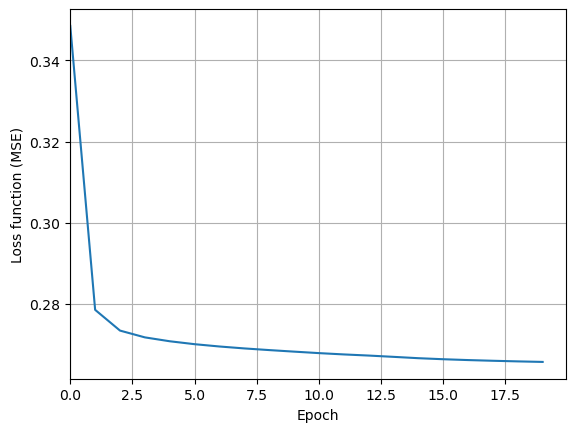

In [39]:
with torch.no_grad():
    best_pred = model(X_val_preprocessed).detach().cpu()

fix, ax = plt.subplots()
# ax.set_ylim(0,None)
print("MSE: %.2f" % best_loss_value)
print("RMSE: %.2f" % np.sqrt(best_loss_value))
ax.plot(loss_history)
ax.set_ylabel('Loss function (MSE)')
ax.set_xlabel('Epoch')
ax.set_xlim(0,None)
ax.grid()
plt.show()

# STEP 3: Make predictions and evaluate the model skill
Once the model is **trained** with the data, we can use it to make predictions.

In [ ]:
y_val_predictions = model(X_val_preprocessed)
y_val_predictions_cpu = y_val_predictions.detach().to('cpu')
y_val_cpu_preprocessed = y_val_preprocessed.detach().to('cpu')
y_val_predictions_cpu = scaler_y.inverse_transform(y_val_predictions_cpu)
y_val_cpu = scaler_y.inverse_transform(y_val_cpu_preprocessed)
y_val_predictions_cpu = scaler_y.inverse_transform(y_val_predictions_cpu)
y_val_cpu = scaler_y.inverse_transform(y_val_cpu)

Once the predictions are ready to be used, we need to transform them back into the original dataspace.

## **QUESTION 4**: Use the `inverse_transform` to return `y_val_predictions_cpu` and `y_val_cpu` to the original data space.

In [ ]:
y_val_predictions_cpu = scaler_y.inverse_transform(y_val_predictions_cpu)
y_val_cpu = scaler_y.inverse_transform(y_val_cpu)

### Plot the predictions against the true data for the validation

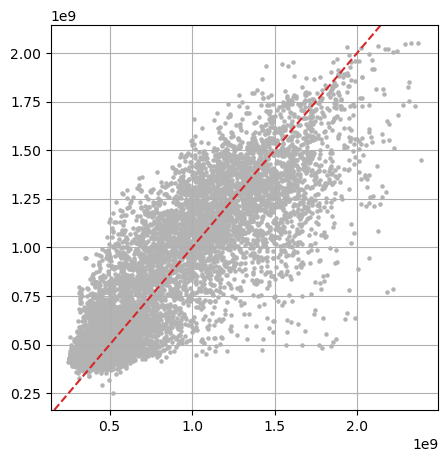

In [33]:
fig, ax = plt.subplots(figsize=(5,5))
ax.scatter(y_val_cpu,y_val_predictions_cpu, s=5, color='.7') 
ax.axline((y_val_cpu.mean(), y_val_cpu.mean()), slope=1, ls='--', color='tab:red')
ax.grid()

In [36]:
rmse = sklearn.metrics.root_mean_squared_error(y_val_cpu, y_val_predictions_cpu)
r2_score = sklearn.metrics.r2_score(y_val_cpu, y_val_predictions_cpu)
print(f"RMSE: {rmse:.02f}")
print(f"R2: {r2_score:.02f}")

RMSE: 232411032.41
R2: 0.73


## **QUESTION 5**: Evaluate the model with the `r2_score` and the `root_mean_square_error`.

In [35]:
rmse = sklearn.metrics.root_mean_squared_error(y_val_cpu, y_val_predictions_cpu)
r2_score = sklearn.metrics.r2_score(y_val_cpu, y_val_predictions_cpu)
print(f"RMSE: {rmse:.02f}")
print(f"R2: {r2_score:.02f}")

RMSE: 232411032.41
R2: 0.73


## **QUESTION 5**: compare the results with the linear regression
Usually, the neural networks will perform better for more complex relationship and non-linear tasks.

<div class="alert alert-block alert-warning">
<b>Note:</b> It is always great to compare neural network results with a much simpler linear model
</div>